# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [1]:
ПІБ = 'Гнатюк Ярослав'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-31'      # напр. 'КН-31'
ВАРІАНТ = 4    # ваш номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [2]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 4 · Гнатюк Ярослав, ШІ-31, «Друк-Сервіс»
Підприємство «Друк-Сервіс» виготовляє поліграфію. Одиниця виміру плану: тис. прим./тиждень.

                          Буклет  Каталог  Календар  Плакат  ЗАПАС
Крейдований папір, кг          5        0         0       0    815
Офсетний папір, кг             1        0         5       2    344
Фарба, кг                      2        4         6       5    840
Друкарська машина, год         3        0         5       3    840
Різка й фальцювання, год       2        1         2       5    382

                    Буклет  Каталог  Календар  Плакат
Прибуток з одиниці      41       50        54      26

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Різка й фальцювання, год
  ціна:   8.3 за одиницю
  обсяг:  до 144 одиниць


In [3]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення: x1 — Буклет, x2 — Каталог, x3 — Календар, x4 — Плакат.

Цільова функція:
max Z = 41·x1 + 50·x2 + 54·x3 + 26·x4

Обмеження:

5·x1 + 0·x2 + 0·x3 + 0·x4 ≤ 815   (крейдований папір)

1·x1 + 0·x2 + 5·x3 + 2·x4 ≤ 344   (офсетний папір)

2·x1 + 4·x2 + 6·x3 + 5·x4 ≤ 840   (фарба)

3·x1 + 0·x2 + 5·x3 + 3·x4 ≤ 840   (друкарська машина)

2·x1 + 1·x2 + 2·x3 + 5·x4 ≤ 382   (різка й фальцювання)

Невід'ємність: x1, x2, x3, x4 ≥ 0

### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:**
Запас це дані, які задані ззовні, ми їх не обираємо, а обираємо лише, скільки зможемо виробити продукції, на яку потрібен цей ресурс. Якби ресурс можна було докупити, з'явилась би змінна "скільки докупити", яка і була б змінною рішення, у цільовій функції її ціна зі знаком мінус, а обмеження мало б вигляд "витрата ≤ запас + докупівля"

---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [4]:
# числа з Excel (Пошук рішення, симплекс-метод)
EXCEL_ПЛАН    = [114.6667, 152.6667, 0, 0]     # оптимальний випуск кожного виробу
EXCEL_ПРИБУТОК = 12334.6667             # значення цільової функції

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [114.6667, 152.6667, 0, 0] | прибуток 12334.6667


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [5]:
r = linprog(-c, A_ub=A, b_ub=b, bounds=(0, None), method='highs')
plan = r.x
прибуток = -r.fun
тіньові = -r.ineqlin.marginals
print('план:', np.round(plan, 4))
print('прибуток: %.4f' % прибуток)
print('тіньові ціни:', np.round(тіньові, 4))

план: [114.6667 152.6667   0.       0.    ]
прибуток: 12334.6667
тіньові ціни: [ 0.      0.      9.8333  0.     10.6667]


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [6]:
assert plan is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(plan, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Крейдований папір, кг | 573,33 | 0 | 815 | 1E+30 | 241,67 |
| Офсетний папір, кг | 114,67 | 0 | 344 | 1E+30 | 229,33 |
| Фарба, кг | 840 | 9,83 | 840 | 688 | 290 |
| Друкарська машина, год | 344 | 0 | 840 | 1E+30 | 496 |
| Різка й фальцювання, год | 382 | 10,67 | 382 | 72,5 | 172 |

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?**

Дефіцитні: фарба і різка й фальцювання - витрачені повністю (кінцеве значення = права частина) і мають ненульову тіньову ціну. Решта три - в надлишку: частина запасу не використана , тіньова ціна 0, тож додатковий запас прибутку не дасть

### Завдання 4.2 — блок «Змінні»

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Буклет | 114,67 | 0 | 41 | 59 | 16 |
| Каталог | 152,67 | 0 | 50 | 32 | 19,75 |
| Календар | 0 | −26,33 | 54 | 26,33 | 1E+30 |
| Плакат | 0 | −76,5 | 26 | 76,5 | 1E+30 |

**У вашому варіанті принаймні один виріб не виробляється зовсім.**
Який саме, і на скільки мусив би зрости прибуток з його одиниці, щоб він увійшов у план? Звідки ви взяли це число?

Не виробляються два: Календар і Плакат. Щоб Календар увійшов у план, прибуток з його одиниці має зрости більш ніж на 26,33 (з 54 до понад 80,33). Для Плаката - більш ніж на 76,5 (з 26 до понад 102,5). Це число - "Зведена вартість" (Reduced Cost) зі звіту Excel, в стовпці "Допустиме збільшення" стоїть те саме значення

---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [7]:
k = int(np.argmax(тіньові))
print('ресурс:', ресурси[k], '| тіньова ціна: %.4f' % тіньові[k])

def solve(bb):
    q = linprog(-c, A_ub=A, b_ub=bb, bounds=(0, None), method='highs')
    return -q.fun

b1 = b.copy(); b1[k] += 1
приріст = solve(b1) - прибуток
print('приріст прибутку при +1: %.4f' % приріст)

ресурс: Різка й фальцювання, год | тіньова ціна: 10.6667
приріст прибутку при +1: 10.6667


**Відповідь 5.1:** приріст прибутку = 10,6667, тіньова ціна зі звіту = 10,67. Збігаються: ще одна година різки й фальцювання дає 10,67 тис. прибутку.

### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

межа діапазону ≈ +72 одиниць (Excel: допустиме збільшення 72,5)


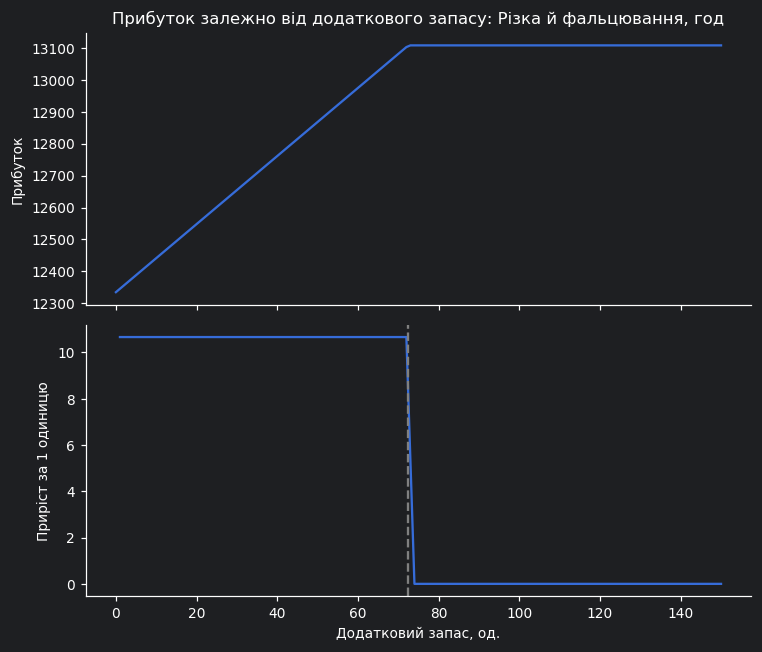

In [8]:
кроки = np.arange(0, 151)
прибутки = []
for s in кроки:
    bb = b.copy(); bb[k] += s
    прибутки.append(solve(bb))
прибутки = np.array(прибутки)
прирости = np.diff(прибутки)

межа = int(np.argmax(np.abs(прирости - тіньові[k]) > 1e-6))
print('межа діапазону ≈ +%d одиниць (Excel: допустиме збільшення 72,5)' % межа)

fig, ax = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
ax[0].plot(кроки, прибутки)
ax[0].set_ylabel('Прибуток')
ax[0].set_title('Прибуток залежно від додаткового запасу: ' + ресурси[k])
ax[1].plot(кроки[1:], прирости)
ax[1].axvline(72.5, ls='--', color='gray')
ax[1].set_ylabel('Приріст за 1 одиницю')
ax[1].set_xlabel('Додатковий запас, од.')
plt.tight_layout(); plt.show()

**Відповідь 5.2:** *(на скільки одиниць можна збільшити запас, доки тіньова ціна не зміниться;
чи збігається знайдена межа з «допустимим збільшенням» зі звіту Excel)*

Тіньова ціна 10,67 тримається, поки запас зростає на 72 одиниці; на кроці 73 приріст падає (тут зростання частково, на 0,5 одиниці), далі дорівнює 0. Точна межа 72,5 збігається з «допустимим збільшенням» зі звіту Excel (72,5). Після неї ресурс вже не дефіцитний: план впирається в інші обмеження.

---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА
* ресурс: Різка й фальцювання, год
* ціна:   8.3 за одиницю
* обсяг:  до 144 одиниць

In [9]:
р = V['ресурс_пропозиції']
ціна = V['ціна_пропозиції']
обсяг = V['обсяг_пропозиції']

допустиме = 72.5
q = min(обсяг, допустиме)
виграш = (тіньові[р] - ціна) * q

bn = b.copy(); bn[р] += q
прямий = solve(bn) - прибуток - ціна * q
print('ресурс: %s | тіньова ціна %.4f | ціна пропозиції %.1f' % (ресурси[р], тіньові[р], ціна))
print('купуємо: %.1f (пропонують %d)' % (q, обсяг))
print('виграш за тіньовою ціною: %.2f' % виграш)
print('виграш прямим розв\'язанням: %.2f' % прямий)

bf = b.copy(); bf[р] += обсяг
print('весь обсяг (%d): виграш %.2f' % (обсяг, solve(bf) - прибуток - ціна * обсяг))

ресурс: Різка й фальцювання, год | тіньова ціна 10.6667 | ціна пропозиції 8.3
купуємо: 72.5 (пропонують 144)
виграш за тіньовою ціною: 171.58
виграш прямим розв'язанням: 171.58
весь обсяг (144): виграш -421.87


**Відповідь 6.1:**

* Брати чи ні і чому: брати. Ціна пропозиції 8,3 менша за тіньову ціну 10,67: кожна куплена одиниця приносить 10,67, а коштує 8,3
* Скільки одиниць має сенс купити і чому не більше: 72,5 (допустиме збільшення зі звіту). Далі ресурс перестає бути дефіцитним, тіньова ціна падає до 0, і додаткові одиниці вже не дають прибутку, а гроші за них доведеться платити. Пропонують 144, потрібно лише половину
* Очікуваний виграш: (10,67 − 8,3) * 72,5 ≈ 171,58
* Перевірка прямим розв'язанням дала: 171,58, збігається. Якщо купити всі 144, виграш виходить від'ємний

---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [10]:
non_zeros_num = int(np.sum(plan > 1e-9))
coherent_num = int(np.sum(np.abs(b - A @ plan) < 1e-9))
print('ненульових:', non_zeros_num, '| зв’язних:', coherent_num)

ненульових: 2 | зв’язних: 2


In [11]:
assert non_zeros_num is not None and coherent_num is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (non_zeros_num, coherent_num))
assert non_zeros_num == coherent_num, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 2 | зв’язних обмежень: 2
Етап 7 пройдено


**Відповідь 7.1:** Числа збіглися: 2 ненульові змінні (Буклет, Каталог) і 2 зв'язні обмеження (фарба, різка й фальцювання)

---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [12]:
plan_rounded = np.round(plan)
is_feasible = bool(np.all(A @ plan_rounded <= b + 1e-9))
print('округлений план:', plan_rounded, '| допустимий:', is_feasible)
print('витрати:', A @ plan_rounded, '| запаси:', b)
print('прибуток округленого: %.2f' % (c @ plan_rounded))

ri = linprog(-c, A_ub=A, b_ub=b, bounds=(0, None), integrality=np.ones(4), method='highs')
print('цілочисельний план:', ri.x, '| прибуток: %.2f' % (-ri.fun))

округлений план: [115. 153.   0.   0.] | допустимий: False
витрати: [575. 115. 842. 345. 383.] | запаси: [815. 344. 840. 840. 382.]
прибуток округленого: 12365.00
цілочисельний план: [114. 153.   0.   0.] | прибуток: 12324.00


**Відповідь 8.1:**

| Варіант | План | Прибуток | Допустимий? |
|---|---|---|---|
| без умови цілочисельності | (114,67; 152,67; 0; 0) | 12 334,67 | так |
| округлений | (115; 153; 0; 0) | 12 365 | ні |
| цілочисельний оптимум | (114; 153; 0; 0) | 12 324 | так |

**Висновок:** Округлений план виглядає найкращим за прибутком, але він недопустимий: не вистачає фарби й різки. Тож округляти не можна, може вийти план, який не виконати. Справжній цілочисельний оптимум трохи менший за дробовий (12 324 проти 12 334,67), і його треба шукати з умовою цілочисельності.

---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [13]:
suppliers = ['Гайсин', 'Ніжин', 'Ананьїв']
consumers = ['Ямпіль', 'Рівне', 'Одеса', 'Суми']
D = np.array([[150, 390, 360, 640],
              [560, 460, 605, 330],
              [260, 570, 140, 700]])
stock = [20, 30, 25]
demand = [14, 19, 27, 15]

assert len(suppliers) == 3 and len(consumers) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(stock) == sum(demand), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=suppliers, columns=consumers)

,Ямпіль,Рівне,Одеса,Суми
Гайсин,150,390,360,640
Ніжин,560,460,605,330
Ананьїв,260,570,140,700


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [14]:
# Розв'язок 1: PuLP
m1 = pulp.LpProblem('transport', pulp.LpMinimize)
x = [[pulp.LpVariable('x_%d_%d' % (i, j), lowBound=0) for j in range(4)] for i in range(3)]
m1 += pulp.lpSum(D[i][j] * x[i][j] for i in range(3) for j in range(4))

імена = []
for i in range(3):
    m1 += (pulp.lpSum(x[i]) == stock[i], 'постач_%d' % i); імена.append('постач_%d' % i)

for j in range(4):
    m1 += (pulp.lpSum(x[i][j] for i in range(3)) == demand[j], 'спож_%d' % j)
    імена.append('спож_%d' % j)

m1.solve(pulp.PULP_CBC_CMD(msg=0))

план1 = np.array([[x[i][j].value() for j in range(4)] for i in range(3)])
вартість1 = pulp.value(m1.objective)
тіні1 = np.array([m1.constraints[n].pi for n in імена])

print('PuLP — план:'); print(pd.DataFrame(план1, index=suppliers, columns=consumers))
print('вартість:', вартість1)
print('тіньові ціни (3 постач. + 4 спож.):', тіні1)

PuLP — план:
         Ямпіль  Рівне  Одеса  Суми
Гайсин     14.0    4.0    2.0   0.0
Ніжин       0.0   15.0    0.0  15.0
Ананьїв     0.0    0.0   25.0   0.0
вартість: 19730.0
тіньові ціни (3 постач. + 4 спож.): [220. 290.   0. -70. 170. 140.  40.]


In [15]:
# Розв'язок 2: linprog
cc = D.flatten()
Aeq = np.zeros((7, 12)); beq = np.array(stock + demand, float)

for i in range(3):
    Aeq[i, i*4:(i+1)*4] = 1

for j in range(4):
    Aeq[3 + j, j::4] = 1

r2 = linprog(cc, A_eq=Aeq, b_eq=beq, bounds=(0, None), method='highs')

план2 = r2.x.reshape(3, 4)
вартість2 = r2.fun
тіні2 = r2.eqlin.marginals

print('linprog — план:'); print(pd.DataFrame(план2, index=suppliers, columns=consumers))
print('вартість:', вартість2)
print('тіньові ціни (3 постач. + 4 спож.):', тіні2)

linprog — план:
         Ямпіль  Рівне  Одеса  Суми
Гайсин     14.0    4.0    2.0   0.0
Ніжин       0.0   15.0    0.0  15.0
Ананьїв     0.0    0.0   25.0   0.0
вартість: 19730.0
тіньові ціни (3 постач. + 4 спож.): [  -0.   70. -220.  150.  390.  360.  260.]


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [16]:
print('вартість: PuLP %.1f | linprog %.1f' % (вартість1, вартість2))
print('плани однакові:', np.allclose(план1, план2))
різниця = тіні2 - тіні1
print('різниця (linprog − PuLP):')
print('  постачальники:', np.round(різниця[:3], 4))
print('  споживачі:    ', np.round(різниця[3:], 4))

вартість: PuLP 19730.0 | linprog 19730.0
плани однакові: True
різниця (linprog − PuLP):
  постачальники: [-220. -220. -220.]
  споживачі:     [220. 220. 220. 220.]


**Відповідь 10.2:**

* Вартість у двох розв'язувачів: однакова, 19 730 км*од
* Тіньові ціни збіглися: ні
* Яку закономірність ви побачили в різниці: для всіх трьох постачальників різниця однакова (−220), для всіх чотирьох споживачів теж однакова (+220), знаки протилежні
* Що це означає для того, хто збирається ухвалювати рішення за цим звітом: обидві відповіді правильні. Сума запасів дорівнює сумі попиту, тому одне з 7 обмежень зайве, і тіньові ціни визначені з точністю до константи: усі "постачальницькі" можна збільшити на t, а "споживацькі" зменшити на t, вартість не зміниться. Кожен розв'язувач вибирає своє t. Тому абсолютні значення тіньових цін нічого не означають. Сенс мають лише різниці між постачальниками і різниці між споживачами (і сума u_i + v_j для пари)

---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [17]:
ненульових_п = int(np.sum(план2 > 1e-9))
звязних_п = int(np.sum(np.abs(Aeq @ r2.x - beq) < 1e-9))
print('ненульових перевезень:', ненульових_п)
print('зв’язних обмежень:', звязних_п, 'з 7')
print('різниця:', звязних_п - ненульових_п)

ненульових перевезень: 6
зв’язних обмежень: 7 з 7
різниця: 1


**Відповідь 11.1:**

* Ненульових перевезень: 6
* Зв'язних обмежень: 7 (усі)
* Чому в транспортній задачі зв'язними виявляються **всі** обмеження: бо вони записані як рівності, тож виконуються «впритул» завжди, а не лише коли ресурс закінчився.
* На скільки ненульових перевезень менше і чому саме на стільки: на 1 (6 проти 7). Одне обмеження залежне: сума запасів = сума попиту, тож його можна вивести з решти шести. Незалежних обмежень 3 + 4 − 1 = 6, і в невиродженому розв'язку стільки ж ненульових змінних.

### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

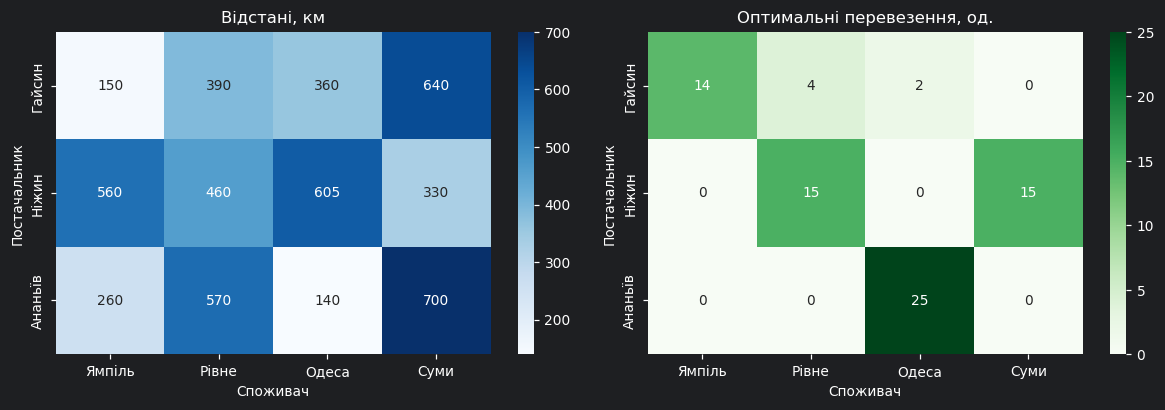

In [18]:
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

sns.heatmap(D, annot=True, fmt='d', cmap='Blues', ax=ax[0], xticklabels=consumers, yticklabels=suppliers)
ax[0].set_title('Відстані, км')
ax[0].set_xlabel('Споживач')
ax[0].set_ylabel('Постачальник')

sns.heatmap(план2, annot=True, fmt='.0f', cmap='Greens', ax=ax[1], xticklabels=consumers, yticklabels=suppliers)
ax[1].set_title('Оптимальні перевезення, од.')
ax[1].set_xlabel('Споживач')
ax[1].set_ylabel('Постачальник')

plt.tight_layout()
plt.show()

**Висновок:** На картах видно, що перевезення йдуть переважно найкоротшими маршрутами: Ананьїв → Одеса (140 км), Гайсин → Ямпіль (150 км), Ніжин → Суми (330 км), а довгі маршрути залишилися порожніми.

---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [19]:
ІНСТРУМЕНТИ_ШІ = 'Claude'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          'ні',
    'етап 2, побудова моделі в Excel':      'код, перевірено',
    'етап 3, код на Python':                'код, перевірено',
    'етапи 4–5, читання та перевірка звіту': 'ні',
    'етап 6, рішення про закупівлю':        'ні',
    'етапи 7–8, перевірка та цілочисельність': 'код, перевірено',
    'етапи 9–11, транспортна задача':       'код, перевірено',
}


# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = """Розв’язав задачу у Excel і отримав звіт про стійкість: план, прибуток, тіньові ціни та діапазони збіглися з розрахунком у Python.
Перевірив вручну витрати ресурсів для оптимального плану, тіньові ціни з системи двох рівнянь для дефіцитних ресурсів, приріст прибутку +1 до запасу різки, межу діапазону 72,5 за графіком приросту.
Перевірив, що округлений план недопустимий, а цілочисельний оптимум (114; 153) допустимий.
У транспортній задачі перевірив, що вартість у PuLP і linprog однакова, а різниця тіньових цін стала для всіх постачальників і для всіх споживачів.
Запустив ноутбук на чистому ядрі."""



# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [20]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                     Гнатюк Ярослав
інструменти:                               Claude
------------------------------------------------------------------------------
етап 1, формалізація моделі:               ні
етап 2, побудова моделі в Excel:           код, перевірено
етап 3, код на Python:                     код, перевірено
етапи 4–5, читання та перевірка звіту:     ні
етап 6, рішення про закупівлю:             ні
етапи 7–8, перевірка та цілочисельність:   код, перевірено
етапи 9–11, транспортна задача:            код, перевірено
------------------------------------------------------------------------------
Розв’язав задачу у Excel і отримав звіт про стійкість: план, прибуток, тіньові ціни та діапазони збіглися з розрахунком у Python.
Перевірив вручну витрати ресурсів для оптимального плану, тіньові ціни з системи двох рівнянь для дефіцитних ресурсів, приріст прибутку +1 до запасу різки, межу діапазону 72,5 за графіко

---
# Крок 13. Фінальна самоперевірка

In [21]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': non_zeros_num == coherent_num,
    'дані транспортної задачі введено': len(suppliers) == 3 and len(consumers) == 4,
    'баланс запасів і попиту': sum(stock) == sum(demand),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
OK     декларацію заповнено

Технічна частина виконана.
Переконайтеся, що заповнені ВСІ клітинки з відповідями,
і виконайте Kernel → Restart & Run All перед здачею.
